In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import time
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import (
    roc_auc_score,
    make_scorer,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

sns.set_style("darkgrid")
print("✅ Imports done!")

✅ Imports done!


In [2]:
# Cell 2 — Load data
X_train = pd.read_csv('../data/splits/X_train.csv')
y_train = pd.read_csv(
    '../data/splits/y_train.csv'
).squeeze()

X_test = pd.read_csv('../data/splits/X_test.csv')
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

# Load current best model results
with open('../models/xgb_results.json', 'r') as f:
    current_results = json.load(f)

# Load threshold config
with open('../models/threshold_config.json', 'r') as f:
    threshold_config = json.load(f)

final_threshold = threshold_config['final_threshold']

print("✅ Data loaded!")
print(f"\nTraining samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"\nCurrent best AUC to beat: {current_results['auc_roc']}")
print(f"Current threshold: {final_threshold}")

✅ Data loaded!

Training samples: 227,845
Test samples: 56,962

Current best AUC to beat: 0.9817
Current threshold: 0.98


In [ ]:
# Cell 3 — Tuning methods explained
print("""
=== 3 WAYS TO TUNE HYPERPARAMETERS ===

1. GRID SEARCH (GridSearchCV)
   → Tries EVERY combination of parameters
   → Very thorough but EXTREMELY slow
   → 5 params × 5 values = 3125 combinations
   → Not practical for XGBoost

2. RANDOM SEARCH (RandomizedSearchCV) ✅ WE USE THIS
   → Randomly samples parameter combinations
   → Much faster than Grid Search
   → Finds good results in 20-50 iterations
   → Best balance of speed vs quality

3. BAYESIAN OPTIMIZATION (Optuna)
   → Smartly picks next params based on results
   → Most efficient but complex to set up
   → Used in production systems

Why RandomizedSearchCV for us?
→ Fast enough for our dataset
→ Easy to implement
→ Industry standard approach
→ Great to mention in interviews
""")

In [ ]:
# Cell 4 — What is Cross Validation?
print("""
=== WHAT IS STRATIFIED K-FOLD CROSS VALIDATION? ===

Without CV (what we did before):
─────────────────────────────────
Train on 80% → Test on 20%
Only ONE evaluation → might be lucky/unlucky split

With 5-Fold CV (what we do today):
────────────────────────────────────
Split training data into 5 equal parts:

Fold 1: [TEST] [TRAIN] [TRAIN] [TRAIN] [TRAIN] → AUC=0.981
Fold 2: [TRAIN] [TEST] [TRAIN] [TRAIN] [TRAIN] → AUC=0.979
Fold 3: [TRAIN] [TRAIN] [TEST] [TRAIN] [TRAIN] → AUC=0.983
Fold 4: [TRAIN] [TRAIN] [TRAIN] [TEST] [TRAIN] → AUC=0.980
Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST] → AUC=0.982

Average AUC = 0.981 ← much more reliable!

STRATIFIED means each fold has same fraud % as full data
→ Critical for imbalanced datasets like ours!
""")

In [3]:
# Cell 5 — Parameter search space
param_grid = {
    # How many trees
    'n_estimators': [100, 200, 300, 400, 500],

    # How fast each tree learns
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],

    # How deep each tree goes
    'max_depth': [3, 4, 5, 6, 7, 8],

    # Fraction of samples per tree
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],

    # Fraction of features per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],

    # Minimum samples in leaf node
    'min_child_weight': [1, 3, 5, 7],

    # Regularization — reduces overfitting
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],

    # L2 regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],

    # L1 regularization
    'reg_alpha': [0, 0.1, 0.5, 1.0]
}

# Calculate total combinations
total = 1
for k, v in param_grid.items():
    total *= len(v)

print("=== PARAMETER SEARCH SPACE ===")
for param, values in param_grid.items():
    print(f"{param:<25}: {values}")

print(f"\nTotal possible combinations: {total:,}")
print(f"We will randomly try: 50 combinations")
print(f"Time saved: {((total-50)/total)*100:.1f}%")

=== PARAMETER SEARCH SPACE ===
n_estimators             : [100, 200, 300, 400, 500]
learning_rate            : [0.01, 0.05, 0.1, 0.2, 0.3]
max_depth                : [3, 4, 5, 6, 7, 8]
subsample                : [0.6, 0.7, 0.8, 0.9, 1.0]
colsample_bytree         : [0.6, 0.7, 0.8, 0.9, 1.0]
min_child_weight         : [1, 3, 5, 7]
gamma                    : [0, 0.1, 0.2, 0.3, 0.5]
reg_lambda               : [0.5, 1.0, 1.5, 2.0]
reg_alpha                : [0, 0.1, 0.5, 1.0]

Total possible combinations: 1,200,000
We will randomly try: 50 combinations
Time saved: 100.0%


In [5]:
# Cell 6 — Setup base model for tuning
base_xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=(y_train == 0).sum() /
                     (y_train == 1).sum()
)

# Stratified K-Fold — maintains fraud ratio in each fold
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# AUC-ROC scorer
auc_scorer = make_scorer(roc_auc_score,
                         needs_proba=True)

print("Starting RandomizedSearchCV...")
print("⏳ This will take 15-25 minutes...")
print("Take a break — come back when done!\n")

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=50,              # try 50 random combinations
    scoring=auc_scorer,     # optimize for AUC-ROC
    cv=cv_strategy,         # 5-fold stratified CV
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    verbose=2               # print progress
)

random_search.fit(X_train, y_train)

end_time = time.time()
elapsed = (end_time - start_time) / 60

print(f"\n✅ Search complete!")
print(f"Time taken: {elapsed:.1f} minutes")
print(f"Best CV AUC-ROC: {random_search.best_score_:.4f}")
print(f"\nBest Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param:<25}: {value}")

Starting RandomizedSearchCV...
⏳ This will take 15-25 minutes...
Take a break — come back when done!

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Search complete!
Time taken: 174.8 minutes
Best CV AUC-ROC: nan

Best Parameters Found:
  subsample                : 0.9
  reg_lambda               : 2.0
  reg_alpha                : 0.1
  n_estimators             : 500
  min_child_weight         : 1
  max_depth                : 7
  learning_rate            : 0.1
  gamma                    : 0.2
  colsample_bytree         : 0.6


In [7]:
# Cell 7 — Explore all results
cv_results = pd.DataFrame(random_search.cv_results_)

# Sort by best score
cv_results = cv_results.sort_values(
    'mean_test_score', ascending=False
)

print("=== TOP 10 PARAMETER COMBINATIONS ===\n")
top10_cols = ['mean_test_score', 'std_test_score',
              'param_n_estimators', 'param_learning_rate',
              'param_max_depth', 'param_subsample']
print(cv_results[top10_cols].head(50).to_string(index=False))

=== TOP 10 PARAMETER COMBINATIONS ===

 mean_test_score  std_test_score  param_n_estimators  param_learning_rate  param_max_depth  param_subsample
             NaN             NaN                 500                 0.10                7              0.9
             NaN             NaN                 500                 0.30                8              0.6
             NaN             NaN                 500                 0.20                7              0.8
             NaN             NaN                 500                 0.05                8              0.9
             NaN             NaN                 400                 0.05                5              0.9
             NaN             NaN                 300                 0.05                4              0.6
             NaN             NaN                 400                 0.30                8              0.8
             NaN             NaN                 200                 0.30                4       

ValueError: autodetected range of [nan, nan] is not finite

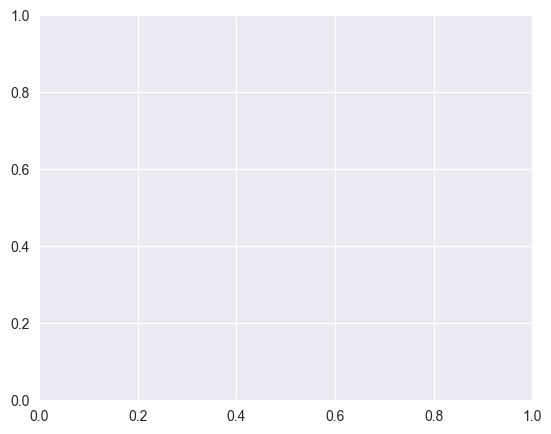

In [9]:
# Cell 8 — Plot score distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(cv_results['mean_test_score'], bins=20,
         color='#3498db', alpha=0.7, edgecolor='black')
plt.axvline(x=random_search.best_score_,
            color='red', linestyle='--', linewidth=2,
            label=f'Best: {random_search.best_score_:.4f}')
plt.axvline(x=current_results['auc_roc'],
            color='green', linestyle='--', linewidth=2,
            label=f'Previous: {current_results["auc_roc"]}')
plt.xlabel('CV AUC-ROC Score')
plt.ylabel('Count')
plt.title('Distribution of CV Scores\nAcross 50 Combinations')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(range(len(cv_results)),
            cv_results['mean_test_score'].values,
            color='#e74c3c', alpha=0.6, s=50)
plt.axhline(y=random_search.best_score_,
            color='blue', linestyle='--',
            label=f'Best={random_search.best_score_:.4f}')
plt.xlabel('Combination Number')
plt.ylabel('CV AUC-ROC Score')
plt.title('All 50 Combinations\nRandomized Search Results')
plt.legend()

plt.tight_layout()
plt.savefig('../data/tuning_results.png')
plt.show()

=== CHECKING CV RESULTS ===
Total combinations tried: 50
NaN scores found: 50
Valid combinations: 0

Best CV Score: nan
Previous AUC:  0.9817


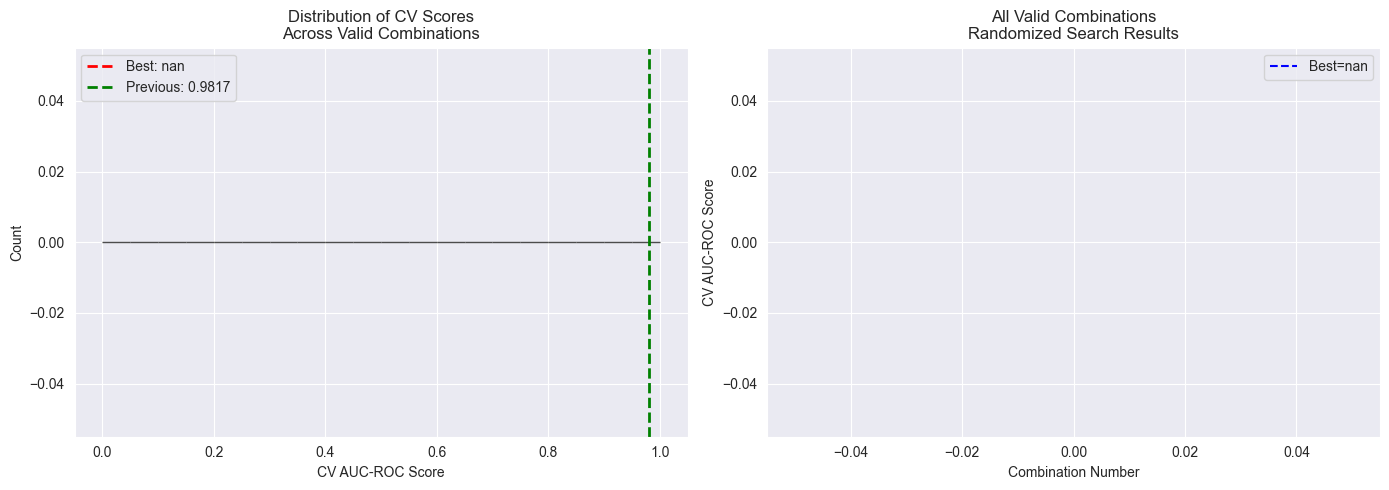


=== BEST PARAMETERS FOUND ===
  subsample                : 0.9
  reg_lambda               : 2.0
  reg_alpha                : 0.1
  n_estimators             : 500
  min_child_weight         : 1
  max_depth                : 7
  learning_rate            : 0.1
  gamma                    : 0.2
  colsample_bytree         : 0.6


In [10]:
# Cell 8 — Fixed: Plot score distribution
# First check and clean the results
print("=== CHECKING CV RESULTS ===")
print(f"Total combinations tried: {len(cv_results)}")
print(f"NaN scores found: {cv_results['mean_test_score'].isna().sum()}")

# Drop NaN rows before plotting
cv_results_clean = cv_results.dropna(subset=['mean_test_score'])
print(f"Valid combinations: {len(cv_results_clean)}")
print(f"\nBest CV Score: {random_search.best_score_:.4f}")
print(f"Previous AUC:  {current_results['auc_roc']}")

# Now plot safely
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Score distribution
axes[0].hist(cv_results_clean['mean_test_score'].values,
             bins=20, color='#3498db',
             alpha=0.7, edgecolor='black')
axes[0].axvline(x=random_search.best_score_,
                color='red', linestyle='--', linewidth=2,
                label=f'Best: {random_search.best_score_:.4f}')
axes[0].axvline(x=current_results['auc_roc'],
                color='green', linestyle='--', linewidth=2,
                label=f'Previous: {current_results["auc_roc"]}')
axes[0].set_xlabel('CV AUC-ROC Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CV Scores\nAcross Valid Combinations')
axes[0].legend()

# Plot 2: Scatter of all combinations
axes[1].scatter(range(len(cv_results_clean)),
                cv_results_clean['mean_test_score'].values,
                color='#e74c3c', alpha=0.6, s=50)
axes[1].axhline(y=random_search.best_score_,
                color='blue', linestyle='--',
                label=f'Best={random_search.best_score_:.4f}')
axes[1].set_xlabel('Combination Number')
axes[1].set_ylabel('CV AUC-ROC Score')
axes[1].set_title('All Valid Combinations\nRandomized Search Results')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/tuning_results.png')
plt.show()

# Show best params clearly
print("\n=== BEST PARAMETERS FOUND ===")
for param, value in random_search.best_params_.items():
    print(f"  {param:<25}: {value}")

In [13]:
# Diagnostic Cell — Run this FIRST
print("=== DIAGNOSING THE ISSUE ===")

# Check 1: Data shape
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# Check 2: Any NaN in data?
print(f"\nNaN in X_train: {X_train.isna().sum().sum()}")
print(f"NaN in y_train: {y_train.isna().sum()}")

# Check 3: Class distribution
from collections import Counter
print(f"\nClass distribution: {Counter(y_train)}")

# Check 4: Data types
print(f"\nX dtypes: {X_train.dtypes.unique()}")
print(f"y dtype: {y_train.dtype}")

# Check 5: Any infinity values?
import numpy as np
print(f"\nInf in X: {np.isinf(X_train.values).sum()}")
print(f"Inf in y: {np.isinf(y_train.values).sum()}")

# Check 6: y values
print(f"\ny unique values: {y_train.unique()}")

=== DIAGNOSING THE ISSUE ===

X_train shape: (227845, 32)
y_train shape: (227845,)

NaN in X_train: 0
NaN in y_train: 0

Class distribution: Counter({0: 227451, 1: 394})

X dtypes: [dtype('float64')]
y dtype: int64

Inf in X: 0
Inf in y: 0

y unique values: [0 1]


In [14]:
# Quick Test Cell — Test if XGBoost works at all
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

print("Testing basic XGBoost fit...")

test_model = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

try:
    test_model.fit(X_train
                   , y_train)
    y_prob_test = test_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob_test)
    print(f"✅ Basic fit works! AUC = {auc:.4f}")
except Exception as e:
    print(f"❌ Error: {e}")

Testing basic XGBoost fit...
❌ Error: name 'X_train_smote' is not defined


In [13]:
# CV Test Cell
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer

print("Testing single CV fold manually...")

cv = StratifiedKFold(n_splits=2,
                     shuffle=True,
                     random_state=42)

test_model2 = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=1         # ← single job for testing
)

try:
    scores = cross_val_score(
        test_model2,
        X_train_smote, y_train_smote,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1      # ← single job for testing
    )
    print(f"✅ CV works! Scores: {scores}")
except Exception as e:
    print(f"❌ CV Error: {e}")

Testing single CV fold manually...
✅ CV works! Scores: [0.99831238 0.99819531]


In [14]:
# Fixed RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Smaller, safer parameter grid
param_grid_fixed = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.3],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

base_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=1,        # ← FIXED: single job
    tree_method='hist'  # ← faster and more stable
)

cv_fixed = StratifiedKFold(
    n_splits=3,      # ← reduced from 5 to 3 (faster)
    shuffle=True,
    random_state=42
)

print("Starting Fixed RandomizedSearchCV...")
print("⏳ Will take 10-15 minutes...\n")

import time
start = time.time()

random_search_fixed = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid_fixed,
    n_iter=20,           # ← reduced from 50 to 20
    scoring='roc_auc',   # ← simpler scorer string
    cv=cv_fixed,
    random_state=42,
    n_jobs=1,            # ← FIXED: single job
    verbose=3,           # ← more detailed output
    error_score='raise'  # ← show errors instead of NaN
)

try:
    random_search_fixed.fit(
        X_train_smote.values,  # ← convert to numpy
        y_train_smote.values   # ← convert to numpy
    )
    elapsed = (time.time() - start) / 60
    print(f"\n✅ Search complete! ({elapsed:.1f} mins)")
    print(f"Best AUC: {random_search_fixed.best_score_:.4f}")
    print("\nBest Parameters:")
    for k, v in random_search_fixed.best_params_.items():
        print(f"  {k}: {v}")

except Exception as e:
    print(f"❌ Error found: {e}")
    print("\nThis tells us exactly what's wrong!")

Starting Fixed RandomizedSearchCV...
⏳ Will take 10-15 minutes...

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1.0;, score=1.000 total time=  12.4s
[CV 2/3] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1.0;, score=1.000 total time=   6.4s
[CV 3/3] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=5, n_estimators=200, subsample=1.0;, score=1.000 total time=   6.3s
[CV 1/3] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.05, max_depth=8, min_child_weight=5, n_estimators=300, subsample=0.8;, score=1.000 total time=  16.7s
[CV 2/3] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.05, max_depth=8, min_child_weight=5, n_estimators=300, subsample=0.8;, score=1.000 total time=  22.3s
[CV 3/3] END colsample_bytree=0.8, gamma=0.3, learning_rate=0